# Predict Health Outcomes of Horses

## Urszula Michalska, Natalia Rogalska

### Goal : 

This is multiclassification task with 3 classes. We want to predict if horse died, live or being euthanized. 

### Column description:

* id : unique ID of horse
* surgery: determines if horse has surgery (binary: yes/no)
* age: determine age of horse (binary: adult/young)
* hospital_number: hospital number given to a horse (numerical: intigers, 255 values)
* rectal_temp: temperature of body measured in rectal way (numerical: floats)
* pulse: determine pulse of horse (numerical, integers)
* respiratory_rate: number of breaths per minute (numerical, integers)
* temp_of_extremities: determines temperature of extremities (categorical: cool/cold/normal/warm)
* peripheral_pulse: determine peripheral pulse (categorical: reduced/normal/absent/increased)
* mucous_membrane: determine color of mucousmembrane (categorical: dark_cyanotic/pale_cyanotic/pale_pink/normal_pink/bright_pink/bright_red)
* capillary_refill_time: time after pressed skin regains color (categorical: more_3_sec/less_3_sec/3)
* pain: describe visible level of pain (categorical: 'depressed' 'mild_pain' 'extreme_pain' 'alert' 'severe_pain'  'slight')
* peristalsis: describes how muscles transport food inside organism (categorical: 'absent' 'hypomotile' 'normal' 'hypermotile','distend_small')
* abdominal_distention: measure if belly is gassy (categorical: 'slight' 'moderate' 'none' 'severe')
* nasogastric_tube: determines if horse need food applied by small tube inserted into nose (categorical: 'slight' 'none' 'significant')
* nasogastric_reflux: backward flux of stomach via nasogastric tube (categorical: 'less_1_liter' 'more_1_liter' 'none' 'slight')
* nasogastric_reflux_ph: ph of nasogastric reflux (numerical: float)
* rectal_exam_feces: characteristic of feces (categorical: 'decreased' 'absent' 'normal' 'increased' 'serosanguious')
* abdomen: describe state of part of body which contains organis near stomach (categorical: 'distend_small' 'distend_large' 'normal' 'firm' 'other')
* packed_cell_volume: percentage of blood volume made up of red blood cells (numerical: integers)
* total_protein: amount of protein in blood (numerical: floats)
* abdomo_appearance: describes how belly looks like (categorical: 'serosanguious' 'cloudy' 'clear')
* abdomo_protein: protein content in abdominal fluid (numerical: floats)
* surgical_lesion: injury produced during surgery (binary: yes/no)
* lesion_1: numerical (integers)
* lesion_2: numerical (integers) 4 unique values
* lesion_3: numerical (integers) 2 unique values
* cp_data: determines if horse has results from clinic test (binary: yes/no)
* outcome: determines state of horse (categorical: died/euthanized/lived)

Note: 'none' is not NaN value, it preserves information

### Scope of work

* Study the data with Exloratory Data Analysis
* Handle missing values with KNN-Imputer
* Encode categorical columns and target
* Use SMOTE technique to oversampling minority classes
* Discussion about feature engineering
* Split the data 
* Models to test
    - KNN
    - Decision Tree
    - Random Forest
    - XGBoost
    - Catboost

* Perform hyperparameter tuning
* Evaluate results
* Generate results for test dataset

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.impute import KNNImputer
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from collections import Counter


In [12]:
train = pd.read_csv("train.csv")

In [4]:
len(train)

1235

In [5]:
train.head()

,id,surgery,age,hospital_number,rectal_temp,pulse,respiratory_rate,temp_of_extremities,peripheral_pulse,mucous_membrane,...,packed_cell_volume,total_protein,abdomo_appearance,abdomo_protein,surgical_lesion,lesion_1,lesion_2,lesion_3,cp_data,outcome
0,0,yes,adult,530001,38.1,132.0,24.0,cool,reduced,dark_cyanotic,...,57.0,8.5,serosanguious,3.4,yes,2209,0,0,no,died
1,1,yes,adult,533836,37.5,88.0,12.0,cool,normal,pale_cyanotic,...,33.0,64.0,serosanguious,2.0,yes,2208,0,0,no,euthanized
2,2,yes,adult,529812,38.3,120.0,28.0,cool,reduced,pale_pink,...,37.0,6.4,serosanguious,3.4,yes,5124,0,0,no,lived
3,3,yes,adult,5262541,37.1,72.0,30.0,cold,reduced,pale_pink,...,53.0,7.0,cloudy,3.9,yes,2208,0,0,yes,lived
4,4,no,adult,5299629,38.0,52.0,48.0,normal,normal,normal_pink,...,47.0,7.3,cloudy,2.6,no,0,0,0,yes,lived


In [6]:
train.describe()

,id,hospital_number,rectal_temp,pulse,respiratory_rate,nasogastric_reflux_ph,packed_cell_volume,total_protein,abdomo_protein,lesion_1,lesion_2,lesion_3
count,1235.0000,1.235000e+03,1235.000000,1235.000000,1235.000000,1235.000000,1235.000000,1235.000000,1235.000000,1235.000000,1235.000000,1235.000000
mean,617.0000,9.545004e+05,38.202186,79.574089,30.054251,4.382591,49.602429,21.388016,3.290931,3832.496356,14.612146,3.577328
std,356.6581,1.356403e+06,0.788668,29.108638,16.452066,1.937357,10.535800,26.676453,1.589195,5436.733774,193.705735,88.858953
min,0.0000,5.213990e+05,35.400000,30.000000,8.000000,1.000000,23.000000,3.500000,0.100000,0.000000,0.000000,0.000000
25%,308.5000,5.288000e+05,37.800000,53.000000,18.000000,2.000000,43.000000,6.600000,2.000000,2205.000000,0.000000,0.000000
50%,617.0000,5.297770e+05,38.200000,76.000000,28.000000,4.500000,48.000000,7.500000,3.000000,2209.000000,0.000000,0.000000
75%,925.5000,5.341450e+05,38.600000,100.000000,36.000000,6.000000,57.000000,9.100000,4.300000,3205.000000,0.000000,0.000000
max,1234.0000,5.305129e+06,40.800000,184.000000,96.000000,7.500000,75.000000,89.000000,10.100000,41110.000000,3112.000000,2209.000000


In [7]:
test = pd.read_csv("test.csv")

In [8]:
test.head()

,id,surgery,age,hospital_number,rectal_temp,pulse,respiratory_rate,temp_of_extremities,peripheral_pulse,mucous_membrane,...,abdomen,packed_cell_volume,total_protein,abdomo_appearance,abdomo_protein,surgical_lesion,lesion_1,lesion_2,lesion_3,cp_data
0,1235,no,adult,534053,38.6,40.0,20.0,normal,normal,normal_pink,...,distend_small,42.0,7.5,clear,2.3,no,0,0,0,no
1,1236,yes,adult,528469,38.2,112.0,48.0,cool,reduced,bright_pink,...,distend_small,44.0,6.0,serosanguious,2.6,no,2208,0,0,yes
2,1237,yes,adult,528178,37.7,66.0,12.0,cool,normal,bright_red,...,distend_small,31.5,6.0,cloudy,1.6,yes,2205,0,0,yes
3,1238,no,adult,534784,37.1,88.0,20.0,cool,reduced,pale_cyanotic,...,distend_large,75.0,81.0,NaN,1.0,yes,1400,0,0,no
4,1239,yes,adult,529840,38.3,50.0,12.0,NaN,normal,bright_pink,...,distend_small,37.0,6.8,cloudy,2.6,yes,2208,0,0,yes


<BarContainer object of 3 artists>

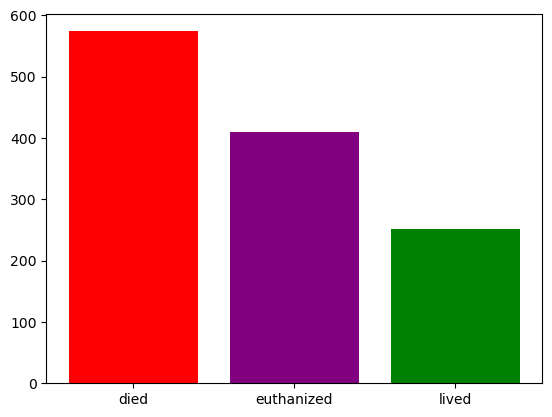

In [9]:
target = train.iloc[:,-1]
plt.figure()
plt.bar(target.unique(), target.value_counts(), color=["red","purple","green"])

In [10]:
train.isnull().sum()

id                         0
surgery                    0
age                        0
hospital_number            0
rectal_temp                0
pulse                      0
respiratory_rate           0
temp_of_extremities       39
peripheral_pulse          60
mucous_membrane           21
capillary_refill_time      6
pain                      44
peristalsis               20
abdominal_distention      23
nasogastric_tube          80
nasogastric_reflux        21
nasogastric_reflux_ph      0
rectal_exam_feces        190
abdomen                  213
packed_cell_volume         0
total_protein              0
abdomo_appearance         48
abdomo_protein             0
surgical_lesion            0
lesion_1                   0
lesion_2                   0
lesion_3                   0
cp_data                    0
outcome                    0
dtype: int64

In [11]:
test.isnull().sum()

id                         0
surgery                    0
age                        0
hospital_number            0
rectal_temp                0
pulse                      0
respiratory_rate           0
temp_of_extremities       35
peripheral_pulse          47
mucous_membrane           13
capillary_refill_time      6
pain                      29
peristalsis               19
abdominal_distention      22
nasogastric_tube          64
nasogastric_reflux        14
nasogastric_reflux_ph      0
rectal_exam_feces        125
abdomen                  154
packed_cell_volume         0
total_protein              0
abdomo_appearance         31
abdomo_protein             0
surgical_lesion            0
lesion_1                   0
lesion_2                   0
lesion_3                   0
cp_data                    0
dtype: int64

## Preprocessing & cleaning pipeline

In [13]:
def cleaning_and_preprocessing(daata, test = False, final_test = False):
    data = daata.copy()

    if final_test == False:
        #drop ID column which has unique values
        data = data.drop(columns=["id"])

    #ensure all categorical columns have the same type and unify entries
    cat_cols = data.select_dtypes(include="object").columns

    for col in cat_cols:
        data[col] = (
            data[col]
            .astype(str)
            .str.strip()
            .str.lower())

    
    #encode categorical columns with visible order

    data['age'] = data['age'].replace(['adult','young'],[1,0])
    data['temp_of_extremities']=data['temp_of_extremities'].replace(['cool','cold','normal','warm'],[1,0,2,3])
    data['peripheral_pulse']=data['peripheral_pulse'].replace(['absent','reduced','normal','increased'],[0,1,2,3])
    data['pain']= data['pain'].replace(['depressed', 'mild_pain' ,'extreme_pain' ,'alert' ,'severe_pain','slight', 'moderate'],[6,2,5,0,4,1,3])
    data['peristalsis'] = data['peristalsis'].replace(['absent', 'hypomotile' ,'normal', 'hypermotile','distend_small'],[4,3,0,2,1])
    data['abdominal_distention'] = data['abdominal_distention'].replace(['none','slight','moderate','severe'],[0,1,2,3])
    data['nasogastric_tube'] = data['nasogastric_tube'].replace(['slight' ,'none' ,'significant'],[1,0,2])
    data['nasogastric_reflux'] = data['nasogastric_reflux'].replace(['less_1_liter', 'more_1_liter' ,'none' ,'slight'],[2,3,0,1])
    data['rectal_exam_feces'] = data['rectal_exam_feces'].replace(['decreased', 'absent', 'normal' ,'increased', 'serosanguious'],[1,3,0,2,4])
    data['abdomen'] = data['abdomen'].replace(['distend_small', 'distend_large', 'normal' ,'firm', 'other'],[1,2,0,3,4])
    data['abdomo_appearance'] = data['abdomo_appearance'].replace(['serosanguious' ,'cloudy', 'clear'],[1,2,0])
    data['mucous_membrane'] = data['mucous_membrane'].replace(['dark_cyanotic','pale_cyanotic','pale_pink','normal_pink','bright_pink','bright_red'],[0,1,2,3,4,5])
    data['capillary_refill_time'] = data['capillary_refill_time'].replace(['more_3_sec','less_3_sec','3'], [2,0,1])

    
    #encode binary columns
    data['surgery'] = data['surgery'].replace(["yes", "no"],[1,0])
    data['surgical_lesion'] = data["surgical_lesion"].replace(["yes", "no"],[1,0])
    data['cp_data'] = data["cp_data"].replace(["yes", "no"],[1,0])

    #Handle target column
    if test!=True:
        data['outcome'] = data['outcome'].replace(['died', 'euthanized', 'lived'], [0,1,2])

    #Impute missing values
    knn = KNNImputer()
    knn.fit(data)
    data_knn = knn.transform(data)
    data = pd.DataFrame(data_knn, columns=data.columns)

    



    return pd.DataFrame(data)

    


problem: difficulty in understand medical terms and establish their order, original_ecoding : same distance between features (may be not equal in medical reasoning)

In [14]:
train = cleaning_and_preprocessing(train)

C:\Users\halsk\AppData\Local\Temp\ipykernel_19512\1993802901.py:21: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['age'] = data['age'].replace(['adult','young'],[1,0])
C:\Users\halsk\AppData\Local\Temp\ipykernel_19512\1993802901.py:37: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['surgery'] = data['surgery'].replace(["yes", "no"],[1,0])
C:\Users\halsk\AppData\Local\Temp\ipykernel_19512\1993802901.py:38: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the 

In [15]:
test = cleaning_and_preprocessing(test, test=True)

C:\Users\halsk\AppData\Local\Temp\ipykernel_12640\1690369686.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['age'] = data['age'].replace(['adult','young'],[1,0])
C:\Users\halsk\AppData\Local\Temp\ipykernel_12640\1690369686.py:36: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['surgery'] = data['surgery'].replace(["yes", "no"],[1,0])
C:\Users\halsk\AppData\Local\Temp\ipykernel_12640\1690369686.py:37: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the 

In [7]:
test_final = pd.read_csv("test.csv")
id = test_final['id']
test_final = cleaning_and_preprocessing(test_final, test=True)

test_final = pd.DataFrame(test_final)
test_final.to_csv("test_final.csv", index = False)

C:\Users\halsk\AppData\Local\Temp\ipykernel_19512\1993802901.py:21: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['age'] = data['age'].replace(['adult','young'],[1,0])
C:\Users\halsk\AppData\Local\Temp\ipykernel_19512\1993802901.py:37: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['surgery'] = data['surgery'].replace(["yes", "no"],[1,0])
C:\Users\halsk\AppData\Local\Temp\ipykernel_19512\1993802901.py:38: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the 

In [9]:
id.head()

id.to_csv("id.csv", index = False)

## Exploratory Data Analysis

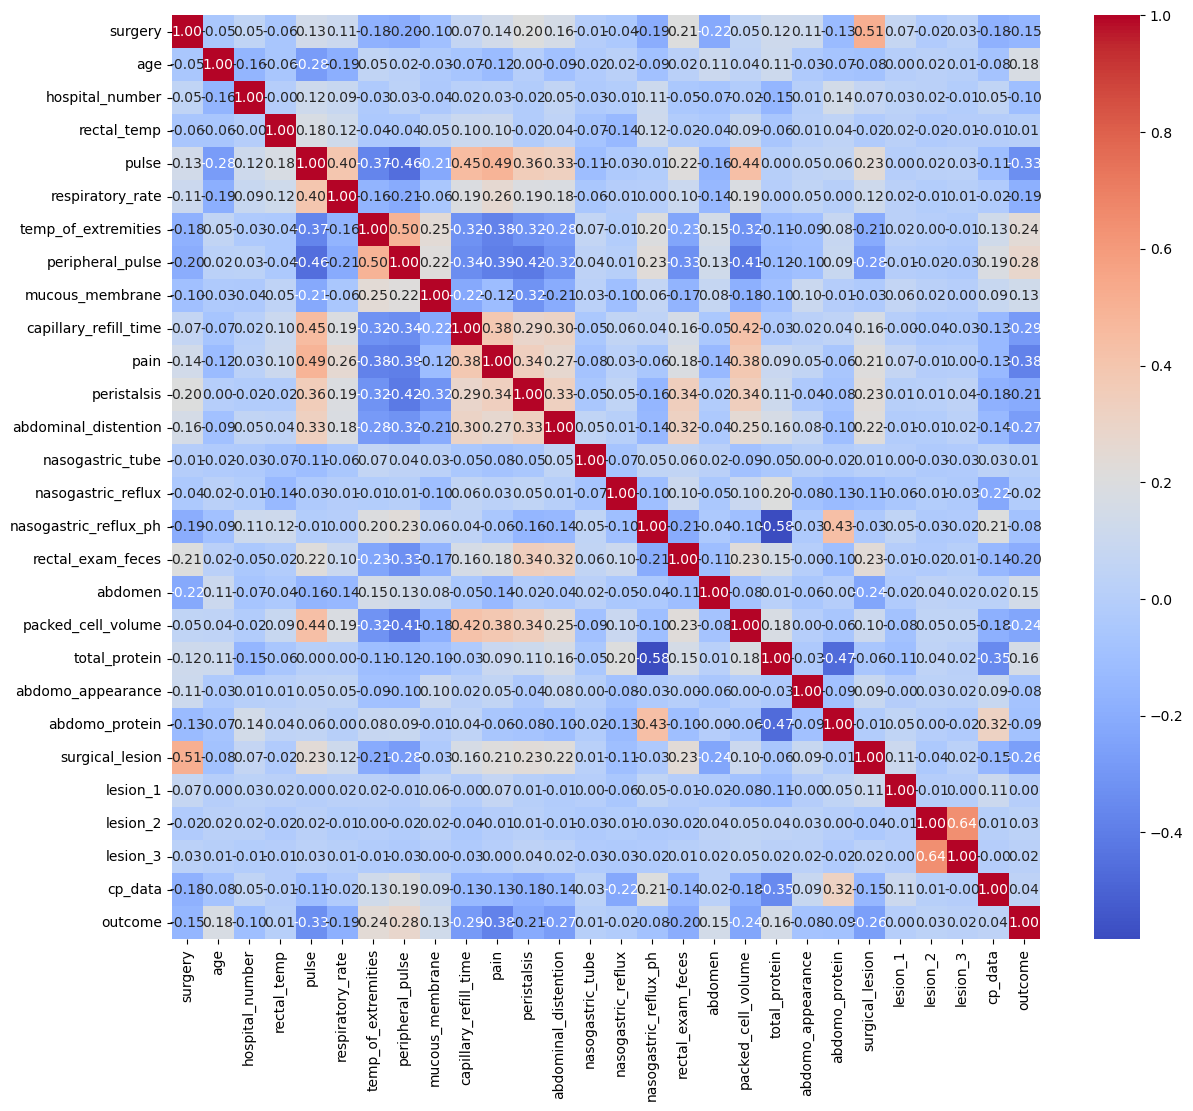

In [16]:
corr = train.corr(numeric_only=True)

plt.figure(figsize=(14, 12))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

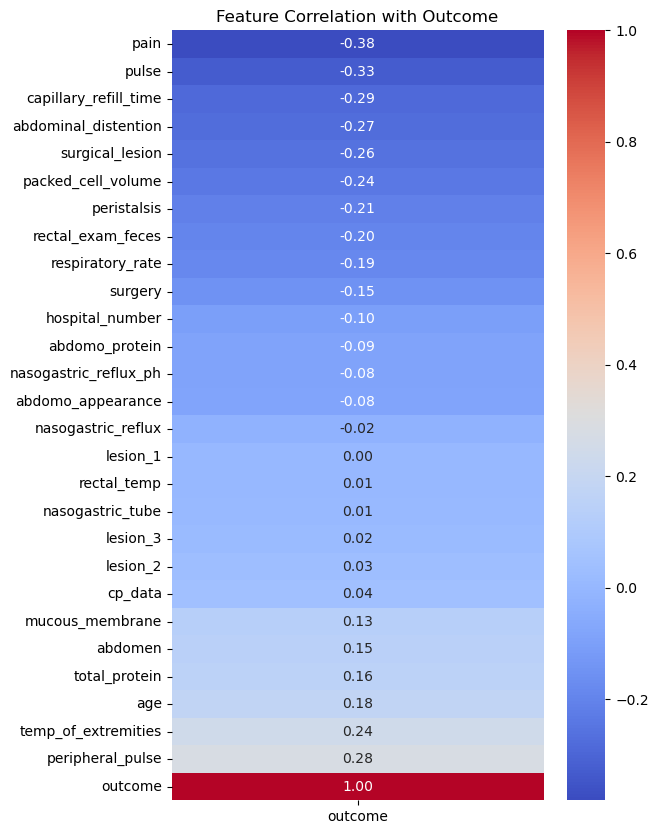

In [17]:
corr = train.corr(numeric_only=True)[["outcome"]].sort_values("outcome")

plt.figure(figsize=(6, 10))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    cbar=True
)
plt.title("Feature Correlation with Outcome")
plt.show()

In [15]:
pulse = train['pulse']
pain = train['pain']
peripheral_pulse = train["peripheral_pulse"]

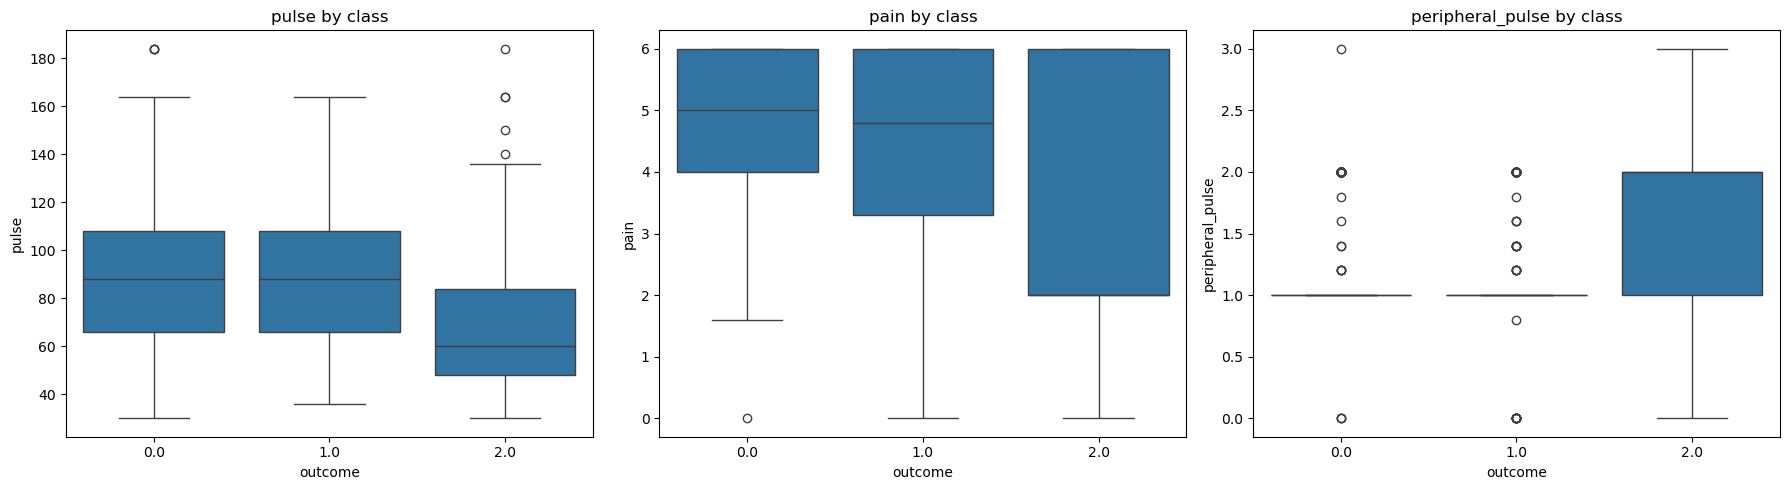

In [16]:
features = ['pulse', 'pain', 'peripheral_pulse']

plt.figure(figsize=(18, 5))
for i, feature in enumerate(features, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(data=train, x='outcome', y=feature)
    plt.title(f'{feature} by class')

plt.tight_layout()
plt.show()

Visualization of data using PCA

Explained variance: [0.16760482 0.09094149]
Cumulative: [0.16760482 0.25854631]


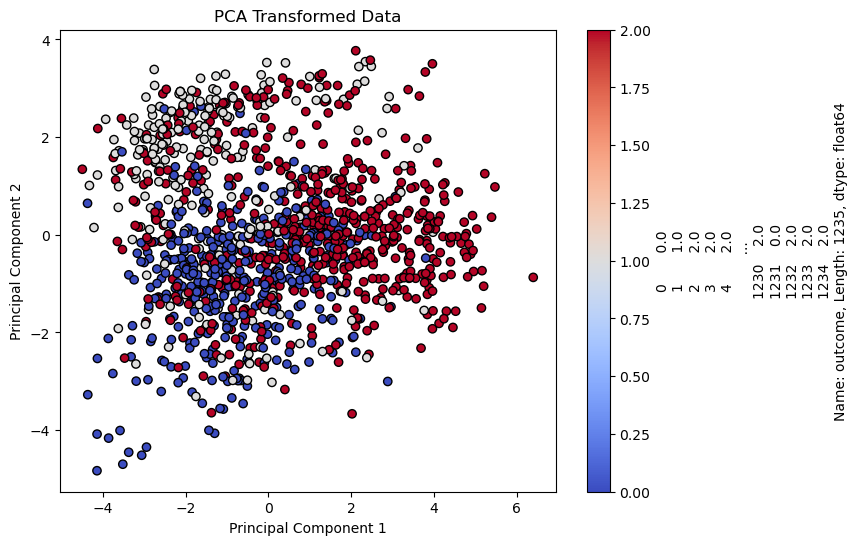

In [18]:
X = train.drop(columns=['outcome'])
y = train['outcome']


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)

print("Explained variance:", pca_2.explained_variance_ratio_)
print("Cumulative:", np.cumsum(pca_2.explained_variance_ratio_))

plt.figure(figsize=(8,6))
plt.scatter(X_pca_2[:, 0], X_pca_2[:, 1], c=y, cmap='coolwarm', edgecolor='k')
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Transformed Data")
plt.colorbar(label=y)
plt.show()

## Oversampling  classes with SMOTE

In [19]:
print("Original class distribution:", Counter(y))
smote = SMOTE(random_state=666)
X_resampled, y_resampled = smote.fit_resample(X, y)
print("Resampled class distribution:", Counter(y_resampled))

X = X_resampled
y = y_resampled

Original class distribution: Counter({2.0: 574, 0.0: 410, 1.0: 251})
Resampled class distribution: Counter({0.0: 574, 1.0: 574, 2.0: 574})


In [29]:
X_train, X_test, y_train, y_test = train_test_split(X,y,stratify=y)

X_train = pd.DataFrame(X_train)
X_train.to_csv("X_train.csv", index = False)

X_test = pd.DataFrame(X_test)
X_test.to_csv("X_test.csv", index = False)

y_train = pd.Series(y_train)
y_train.to_csv("y_train.csv", index = False)

y_test = pd.Series(y_test)
y_test.to_csv("y_test.csv", index = False)